In [1]:
%load_ext autoreload
%autoreload 2
import pylupnt as pnt
import numpy as np
import utils
import plotting
import pprint
pp = pprint.PrettyPrinter()
# Backend for matplotlib (inline, TkAgg, Qt5Agg, WXAgg, GTKAgg, Agg, ps, pdf, svg, cairo, Macosx, WebAgg, nbAgg, template)
%matplotlib widget

# Experiment 1

## Users

In [2]:
import pathfinder_data

orbital_elements = pathfinder_data.orbital_elements.copy()
users = pathfinder_data.users.copy()

# Epoch (TAI)
epoch_0 = pnt.SpiceInterface.string_to_tai("2026/1/01 00:00:00.000 UTC")

# Classical orbital elements (a, e, i, W, w, M) [km, -, rad, rad, rad, rad]
coe_OP = orbital_elements
coe_OP[2:] = np.deg2rad(coe_OP[2:])
rv0_moon_sat_OP = pnt.classical_to_cartesian(coe_OP, pnt.MU_MOON)
rv0_moon_sat_mi = pnt.CoordConverter.convert(epoch_0, rv0_moon_sat_OP, pnt.OP, pnt.MI)

# Time
sma = coe_OP[0]  # [km] Semi-major axis
period = 2 * np.pi * np.sqrt(np.power(sma, 3) / pnt.MU_MOON)  # [s] Orbital period
Dt = 5 * pnt.SECS_PER_MINUTE  # [s] Simulation time step
dt = 5 * pnt.SECS_PER_MINUTE  # [s] Propagation time step
tf = 1 * pnt.SECS_PER_DAY  # [s] Simulation final time
N_t = int(tf / Dt)  # [-] Number of time steps
tspan = np.linspace(0, tf, N_t)  # [s] Time since first epoch
epochs = epoch_0 + tspan  # [s] Epochs (TAI)

# Dynamics (three-body)
dynamics = pnt.NBodyDynamics()
dynamics.set_primary_body(pnt.Body.Moon())
dynamics.add_body(pnt.Body.Earth())
dynamics.set_time_step(dt)

# Propagation
# rv_{from}_{to}_{frame} [km, km/s] (x, y, z, vx, vy, vz)
rv_moon_sat_mi = dynamics.propagate(rv0_moon_sat_mi, epoch_0, epochs)
rv_moon_sat_pa = pnt.CoordConverter.convert(epochs, rv_moon_sat_mi, pnt.MI, pnt.PA)
rv_moon_earth_mi = pnt.SpiceInterface.get_body_pos_vel(epochs, pnt.MOON, pnt.EARTH)
rv_moon_earth_pa = pnt.CoordConverter.convert(epochs, rv_moon_earth_mi, pnt.MI, pnt.PA)
rv_moon_sun_mi = pnt.SpiceInterface.get_body_pos_vel(epochs, pnt.MOON, pnt.SUN)
rv_moon_sun_pa = pnt.CoordConverter.convert(epochs, rv_moon_sun_mi, pnt.MI, pnt.PA)

Loaded All SPICE Kernels
Loaded Chebyshev coefficients for 14 planets.


In [3]:
def propagate_orbital_user(user: dict) -> np.array:
    """
    Propagate a user on orbit around the Moon.
    :param coe: [a, e, i, W, w, M] [km, -, deg, deg, deg, deg]
    :param frame: Frame
    :return: [x, y, z, vx, vy, vz] [km, km/s]
    """
    coe = user["orbital_elements"].copy()
    frame = user["frame"]
    coe[2:] = np.deg2rad(coe[2:])
    rv0 = pnt.classical_to_cartesian(coe, pnt.MU_MOON)
    rv0_mi = pnt.CoordConverter.convert(epoch_0, rv0, frame, pnt.MI)
    rv_mi = dynamics.propagate(rv0_mi, epoch_0, epochs)
    return rv_mi


def propagate_surface_user(user: dict) -> np.array:
    """
    Propagate a user on the surface of the Moon.
    :param lat_lon_alt: [lat, lon, alt] [deg, deg, km]
    :return: [x, y, z, vx, vy, vz] [km, km/s]
    """
    lat_lon_alt = user["location"].copy()
    lat_lon_alt[:2] = np.deg2rad(lat_lon_alt[:2])
    rv_pa = np.zeros((N_t, 6))
    rv_pa[:, :3] = pnt.geographical_to_cartesian(lat_lon_alt, pnt.R_MOON)
    return rv_pa


# Users
N_users = len(users)
user_type = np.array([user["type"] for user in users])
rv_moon_user_mi = np.zeros((N_users, N_t, 6))
rv_moon_user_pa = np.zeros((N_users, N_t, 6))
az_el_rho = np.zeros((N_users, N_t, 3))
for i, user in enumerate(users):
    if user["type"] == "orbital":
        rv_moon_user_mi[i] = propagate_orbital_user(user)
        rv_moon_user_pa[i] = pnt.CoordConverter.convert(
            epochs, rv_moon_user_mi[i], pnt.MI, pnt.PA
        )
    elif user["type"] == "surface":
        rv_moon_user_pa[i] = propagate_surface_user(user)
        rv_moon_user_mi[i] = pnt.CoordConverter.convert(
            epochs, rv_moon_user_pa[i], pnt.PA, pnt.MI
        )
    else:
        raise ValueError("Invalid user type")

    az_el_rho[i] = pnt.cartesian_to_azimuth_elevation_range(
        rv_moon_user_mi[i, :, :3], rv_moon_sat_mi[:, :3]
    )

surface_elev_mask = np.deg2rad(15)  # [rad] Elevation mask
orbital_elev_mask = np.deg2rad(2)  # [rad] Elevation mask
max_elevation = np.max(az_el_rho[:, :, 1], axis=1)
min_elevation = np.maximum(surface_elev_mask, max_elevation - np.deg2rad(90))
min_elevation[user_type == "orbital"] = orbital_elev_mask
print("Max elevation (geometry)   ", np.rad2deg(max_elevation).round(0))
print("Min elevation (requirement)", np.rad2deg(min_elevation).round(0))
user_visible = np.greater_equal(az_el_rho[:, :, 1], min_elevation[:, None])

Max elevation (geometry)    [79. 55. 42. 64. 79. 18.]
Min elevation (requirement) [ 2. 15. 15. 15.  2. 15.]


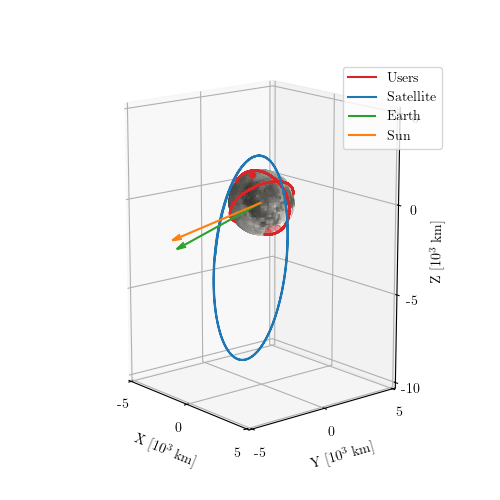

In [4]:
plotting.plot_satellites_users(
    rv_moon_sat_mi, rv_moon_user_mi, rv_moon_earth_mi, rv_moon_sun_mi, user_type
)

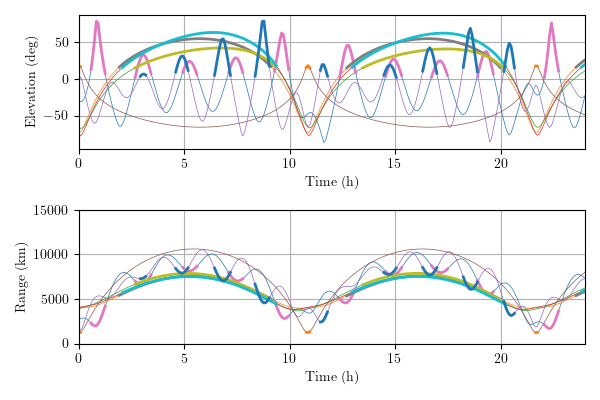

In [5]:
plotting.plot_elevation_range(tspan, az_el_rho, user_visible)

In [6]:
contact_durations = list[np.array]()
contact_start_ends = list[np.array]()
for i, user in enumerate(users):
    starts, ends = utils.get_start_end_indexes(user_visible[i])
    contact_start_ends.append(np.vstack((starts, ends)).T)
    contact_durations.append((ends - starts) * Dt / pnt.SECS_PER_MINUTE)
total_contact_durations = np.array([x.sum() for x in contact_durations])
contact_durations_pathfinder = np.array([user["contact"] for user in users])

print("Contact durations [min]")
pp.pprint(contact_durations)
print("Total contact durations [min]")
pp.pprint(total_contact_durations)
print("Pathfinder contact durations [min]")
pp.pprint(contact_durations_pathfinder)

Contact durations [min]
[array([45., 50., 45., 45., 45., 50., 50., 50., 50., 45.]),
 array([435., 440.,  30.]),
 array([400., 400.]),
 array([440., 440.,  15.]),
 array([ 5., 20., 40., 50., 45., 25., 40., 45., 45., 35.]),
 array([10., 15., 10.])]
Total contact durations [min]
array([475., 905., 800., 895., 350.,  35.])
Pathfinder contact durations [min]
array([150, 467, 529, 248, 100,  23])


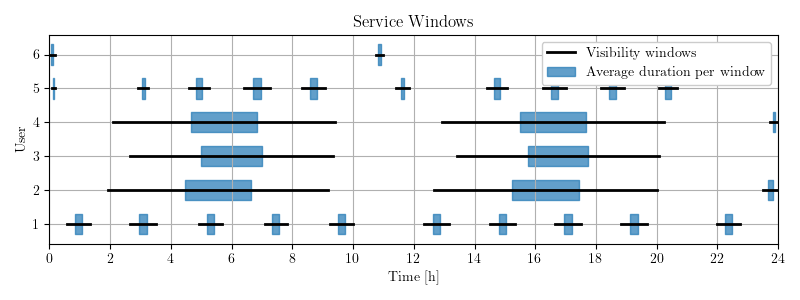

In [7]:
import matplotlib.pyplot as plt

duration_factor = 0.3
time_multiplier = Dt / pnt.SECS_PER_HOUR
plotting.plot_service_windows(contact_start_ends, duration_factor, time_multiplier)
plt.xlim(0, tf / pnt.SECS_PER_HOUR)
plt.xticks(np.arange(0, tf / pnt.SECS_PER_HOUR + 1, 2))
plt.tight_layout()
plt.show()

In [8]:
from algorithms import Request, ServiceWindow

# Requests
requests = list[Request]()
resquest_id = 0
for i, user in enumerate(users):
    requests.append(
        Request(
            id=resquest_id,
            user_id=user["id"],
            rv=rv_moon_user_mi[i],
            start=0,
            end=int(pnt.SECS_PER_DAY / Dt),
            duration=total_contact_durations[i] * duration_factor,
        )
    )
    resquest_id += 1

N_requests = len(requests)
print("Requests:", N_requests)
pp.pprint(requests)

Requests: 6
[Request(id=0, user_id=1, start=0, end=288, duration=142.5),
 Request(id=1, user_id=2, start=0, end=288, duration=271.5),
 Request(id=2, user_id=3, start=0, end=288, duration=240.0),
 Request(id=3, user_id=4, start=0, end=288, duration=268.5),
 Request(id=4, user_id=5, start=0, end=288, duration=105.0),
 Request(id=5, user_id=6, start=0, end=288, duration=10.5)]


In [9]:
# Service windows
service_windows = list[ServiceWindow]()
window_id = 0
for i, request in enumerate(requests):
    for start, end in contact_start_ends[i]:
        service_windows.append(
            ServiceWindow(
                id=window_id,
                request_id=request.id,
                start=start,
                end=end,
                reward=1,
                power_gen=-1,
                data_gen=1,
            )
        )
        window_id += 1
N_service_windows = len(service_windows)
print("Service windows:", N_service_windows)
pp.pprint(service_windows[:3])

Service windows: 31
[ServiceWindow(id=0,
               request_id=0,
               start=7,
               end=16,
               reward=1,
               power_gen=-1,
               data_gen=1),
 ServiceWindow(id=1,
               request_id=0,
               start=32,
               end=42,
               reward=1,
               power_gen=-1,
               data_gen=1),
 ServiceWindow(id=2,
               request_id=0,
               start=59,
               end=68,
               reward=1,
               power_gen=-1,
               data_gen=1)]


In [10]:
# Transition times
transition_times = np.ones((N_service_windows, N_service_windows))
transition_times[np.diag_indices(N_service_windows)] = 0

In [11]:
from algorithms import PntSchedulingProblem, SmdpForwardSearchSolver, SmdpMctsSolver, State

In [12]:
problem = PntSchedulingProblem(
    requests=requests,
    service_windows=service_windows,
    transition_times=transition_times,
    N_max_actions=50,
    min_action_duration=25,
)

s = problem.initial_state()
# solver = SmdpMcts(problem)
# policy = solver.solve(s, d=3, n=1000, c=3, gamma=0.9)

# Toy Problem

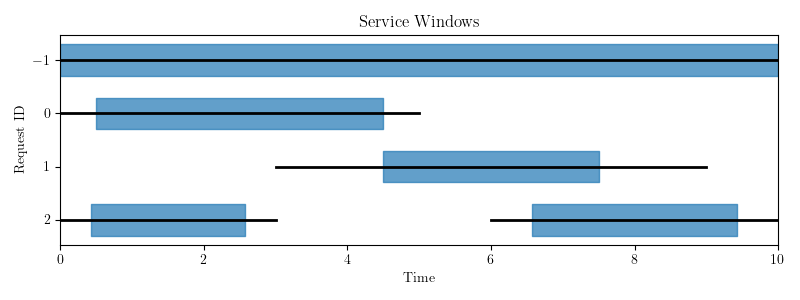

In [31]:
from algorithms import PntSchedulingProblem, SmdpForwardSearchSolver, SmdpMctsSolver, State, Action

requests = [
    Request(id=-1, user_id=-1, rv=None, start=0, end=10, duration=10), # Dummy request
    Request(id=0, user_id=1, rv=None, start=0, end=10, duration=4),
    Request(id=1, user_id=2, rv=None, start=0, end=10, duration=3),
    Request(id=2, user_id=3, rv=None, start=0, end=10, duration=5),
]

service_windows = [
    ServiceWindow(
        id=-1, request_id=-1, start=0, end=10, reward=0, power_gen=0, data_gen=0
    ), # Dummy service window
    ServiceWindow(
        id=0, request_id=0, start=0, end=5, reward=1, power_gen=-1, data_gen=1
    ),
    ServiceWindow(
        id=1, request_id=1, start=3, end=9, reward=2, power_gen=-1, data_gen=1
    ),
    ServiceWindow(
        id=2, request_id=2, start=0, end=3, reward=3, power_gen=-1, data_gen=1
    ),
    ServiceWindow(
        id=2, request_id=2, start=6, end=10, reward=5, power_gen=-1, data_gen=1
    ),
]

transition_times = np.ones((len(service_windows), len(service_windows)))
transition_times[np.diag_indices(len(service_windows))] = 0

problem = PntSchedulingProblem(
    requests=requests,
    service_windows=service_windows,
    transition_times=transition_times,
    N_max_actions=50,
    min_action_duration=1,
    max_energy=10,
    min_energy=2,
    max_data=10,
    min_data=2,
)

plotting.plot_requests_service_windows(requests, service_windows)

Total reward: 6.20


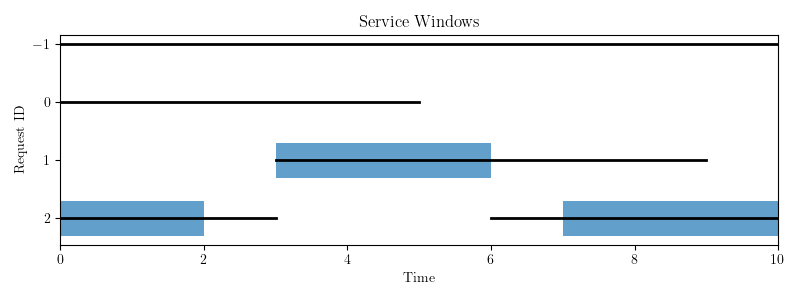

In [39]:
# Forward search
s = problem.initial_state()
solver = SmdpForwardSearchSolver(problem)
policy = solver.solve(s, d=5, gamma=0.9)
plotting.plot_requests_service_windows(requests, service_windows, policy)
print(f"Total reward: {problem.total_reward(policy):.2f}")

Total reward: 6.20


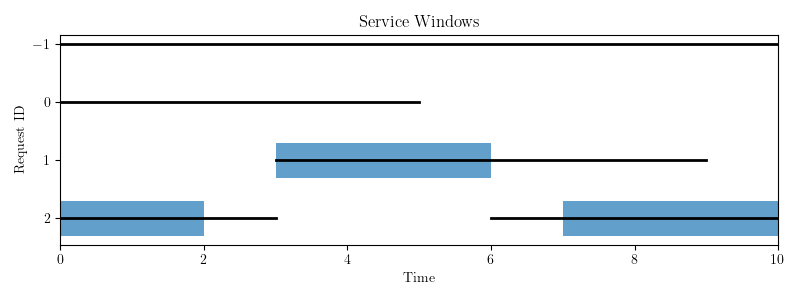

In [85]:
# MCTS
s = problem.initial_state()
solver = SmdpMctsSolver(problem)
policy = solver.solve(s, d=10, gamma=0.9, n=1000, c=10)
plotting.plot_requests_service_windows(requests, service_windows, policy)
print(f"Total reward: {problem.total_reward(policy):.2f}")

optimal
Total reward: 6.20


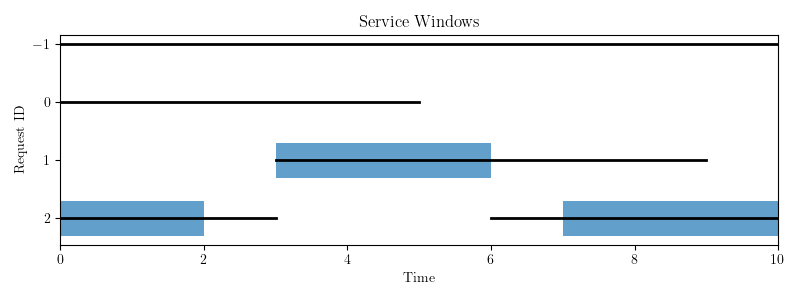

In [86]:
from algorithms import DiscreteTimeIpSolver

# IP
solver = DiscreteTimeIpSolver(problem)
policy = solver.solve(s, time_step=1)
plotting.plot_requests_service_windows(requests, service_windows, policy)
print(f"Total reward: {problem.total_reward(policy):.2f}")